# Proteomics-Toolkit Tutorial

This tutorial walks through a complete analysis using the bundled example
dataset: a small, simulated Skyline-PRISM experiment with two groups
(`Control` vs `Treatment`), six samples per group, and 80 proteins with 60
peptides across the 20 most abundant proteins.

**Pipeline:**
1. Load the example dataset (protein + peptide + metadata + sequences)
2. Run QC plots (missing values, identifications, intensity distributions, CV)
3. Build the standardized annotation + sample table (including `n_peptides` for the DEqMS moderation)
4. Run differential analysis with the moderated linear model:
   - 4a. Welch's t-test (baseline, no moderation)
   - 4b. `moderation="limma"` — global empirical Bayes prior
   - 4c. `moderation="deqms"` — peptide-count-conditioned prior, with its diagnostic plot
   - 4d. `moderation="intensity_trend"` *(default)* — Python equivalent of limma-trend, with its diagnostic plot
5. Visualise results (volcano, PCA)
6. Inspect peptide coverage for a significant protein
7. Export results

## 1. Load the example dataset

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

import proteomics_toolkit as ptk

protein_data, peptide_data, metadata, sample_cols, protein_sequences = (
    ptk.datasets.load_example_data()
)
print(f"protein_data:      {protein_data.shape}")
print(f"peptide_data:      {peptide_data.shape}")
print(f"metadata:          {metadata.shape}")
print(f"sample_cols:       {len(sample_cols)} samples")
print(f"protein_sequences: {len(protein_sequences)} entries (keyed by leading_protein + accession)")
metadata

The PRISM batch-suffix convention (`__@__Batch1`) is baked into the sample
column names. Build a dict mapping each full sample column to its metadata
row so the stats functions can look up group membership.

In [14]:
col_map = ptk.strip_batch_suffix(sample_cols)
short_to_col = {v: k for k, v in col_map.items()}

meta_dict = {}
for _, row in metadata.iterrows():
    full_col = short_to_col.get(row['Replicate'])
    if full_col:
        meta_dict[full_col] = row.to_dict()

list(meta_dict.items())[:2]

Detected common batch suffix: '__@__Batch1'


[('Ctrl_01__@__Batch1',
  {'Replicate': 'Ctrl_01',
   'Group': 'Control',
   'Subject': 'Subj1',
   'Batch': 'Batch1'}),
 ('Ctrl_02__@__Batch1',
  {'Replicate': 'Ctrl_02',
   'Group': 'Control',
   'Subject': 'Subj2',
   'Batch': 'Batch1'})]

## 2. Quality-control plots

Inspect data quality before any filtering or normalization.

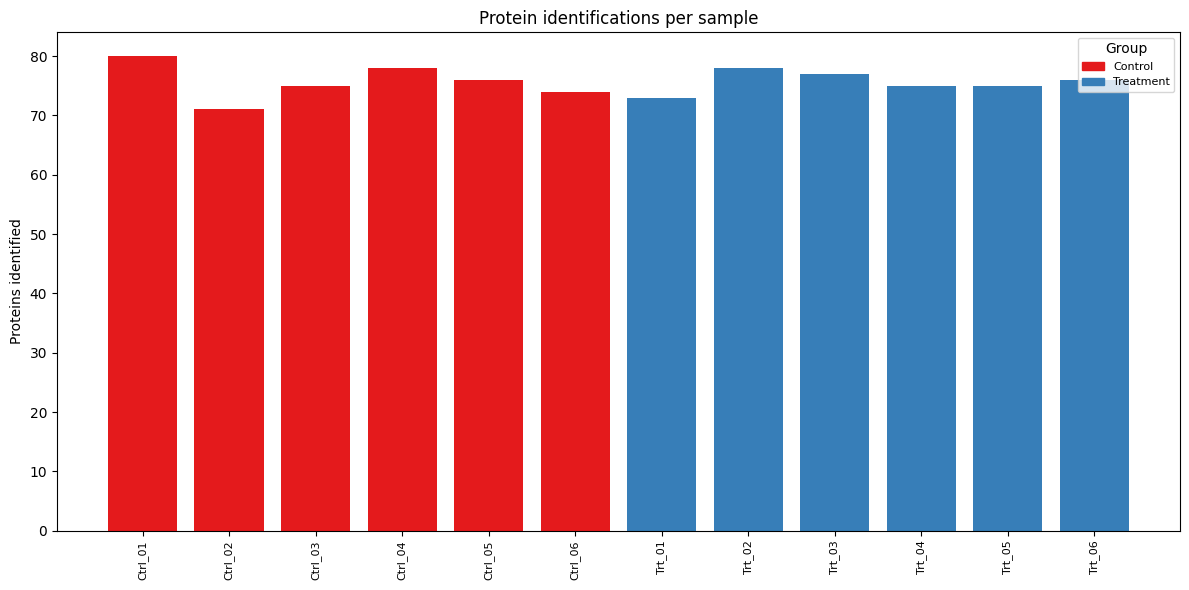

In [15]:
ptk.plot_identifications_per_sample(protein_data, sample_cols, sample_metadata=meta_dict)
plt.show()

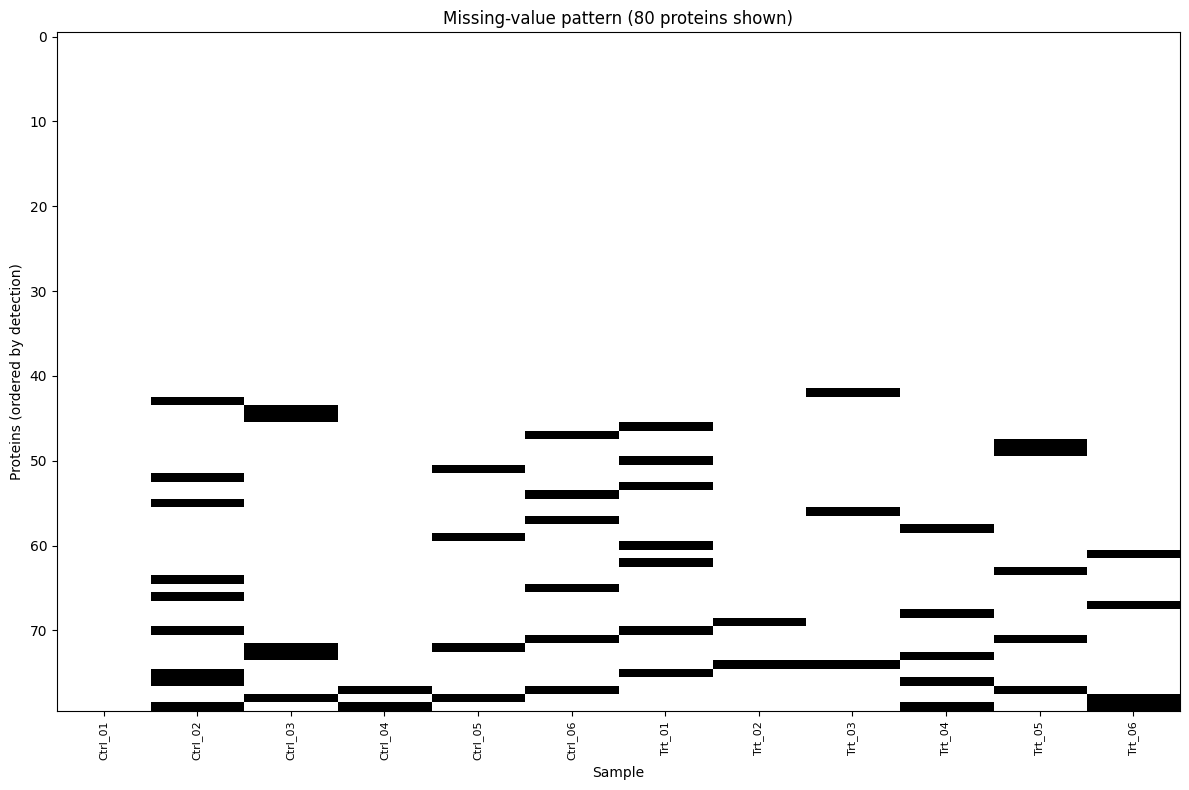

In [16]:
ptk.plot_missing_value_heatmap(protein_data, sample_cols)
plt.show()

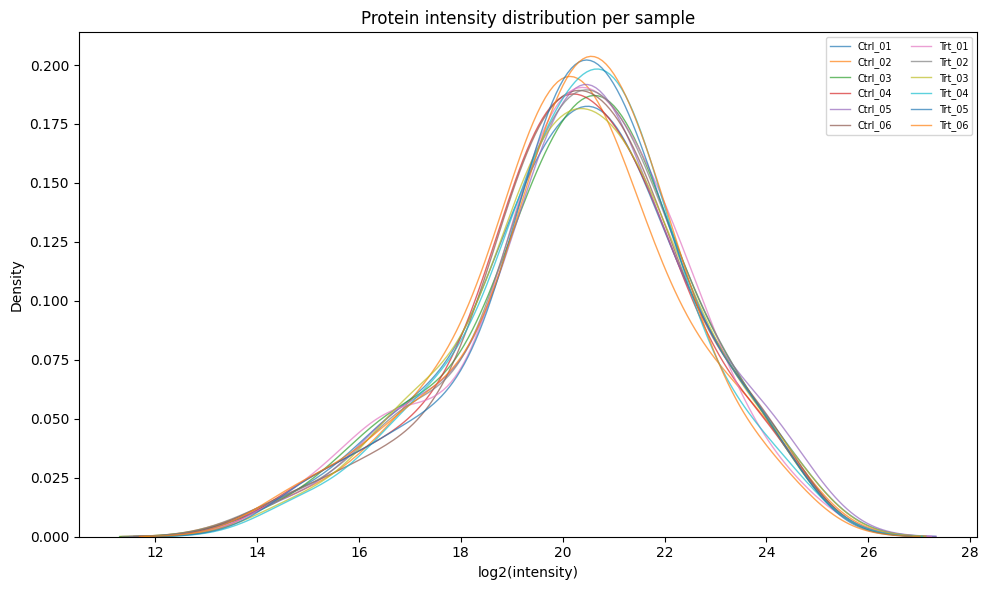

In [17]:
ptk.plot_intensity_distributions(protein_data, sample_cols)
plt.show()

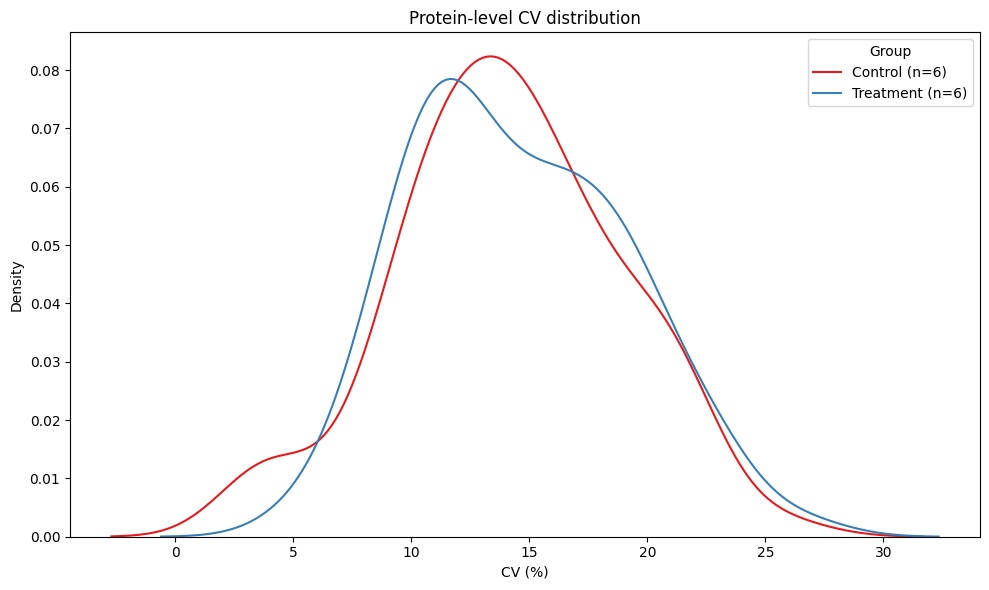

In [18]:
ptk.plot_cv_distribution(protein_data, sample_cols, sample_metadata=meta_dict)
plt.show()

## 3. Build the standardized annotation + sample table

The toolkit's statistical and visualization functions expect a DataFrame
with the 5 standard annotation columns first, then sample columns.
We also keep `n_peptides` alongside the sample columns so `deqms_like`
can use it below for peptide-count-conditioned variance shrinkage.

In [19]:
annot = protein_data[[
    'leading_protein', 'leading_description', 'leading_gene_name',
    'leading_uniprot_id', 'leading_name',
]].copy()
annot.columns = ['Protein', 'Description', 'Protein Gene', 'UniProt_Accession', 'UniProt_Entry_Name']

data = pd.concat(
    [
        annot.reset_index(drop=True),
        protein_data[['n_peptides']].reset_index(drop=True),
        protein_data[sample_cols].reset_index(drop=True),
    ],
    axis=1,
)
data.head()

,Protein,Description,Protein Gene,UniProt_Accession,UniProt_Entry_Name,n_peptides,Ctrl_01__@__Batch1,Ctrl_02__@__Batch1,Ctrl_03__@__Batch1,Ctrl_04__@__Batch1,Ctrl_05__@__Batch1,Ctrl_06__@__Batch1,Trt_01__@__Batch1,Trt_02__@__Batch1,Trt_03__@__Batch1,Trt_04__@__Batch1,Trt_05__@__Batch1,Trt_06__@__Batch1
0,sp|P02768|ALBU_HUMAN,Serum albumin,ALB,P02768,ALBU_HUMAN,17,4.423031e+05,5.470444e+05,5.162385e+05,5.127478e+05,4.701820e+05,NaN,9.263555e+05,7.447212e+05,6.059551e+05,8.212277e+05,NaN,1.217673e+06
1,sp|P02787|TRFE_HUMAN,Serotransferrin,TF,P02787,TRFE_HUMAN,11,1.307837e+06,1.195362e+06,1.531830e+06,9.746208e+05,1.090112e+06,NaN,2.644828e+06,2.578593e+06,2.827408e+06,2.588548e+06,3.166579e+06,1.967900e+06
2,sp|P00738|HPT_HUMAN,Haptoglobin,HP,P00738,HPT_HUMAN,9,5.847170e+06,7.063453e+06,NaN,4.813015e+06,5.727768e+06,5.436432e+06,3.230358e+06,2.780178e+06,3.120327e+06,3.339477e+06,2.115289e+06,2.981594e+06
3,sp|P01023|A2MG_HUMAN,Alpha-2-macroglobulin,A2M,P01023,A2MG_HUMAN,8,2.688341e+06,2.072741e+06,2.046111e+06,2.844585e+06,2.241062e+06,2.600312e+06,1.123542e+06,1.125382e+06,7.829250e+05,1.028315e+06,9.014166e+05,7.229723e+05
4,sp|P02765|FETUA_HUMAN,Alpha-2-HS-glycoprotein,AHSG,P02765,FETUA_HUMAN,15,1.207554e+06,1.298719e+06,NaN,1.257872e+06,1.211298e+06,1.188812e+06,2.177329e+06,3.158637e+06,2.339660e+06,2.275244e+06,2.582757e+06,3.467423e+06


## 4. Statistical analysis

### 4a. Welch's t-test (baseline)

Per-protein Welch's t-test with FDR correction. This is the straightforward
two-sample comparison; it uses each protein's own variance estimate.

In [20]:
config = ptk.StatisticalConfig()
config.analysis_type = 'unpaired'
config.statistical_test_method = 'welch_t'
config.group_column = 'Group'
config.group_labels = ['Control', 'Treatment']
config.correction_method = 'fdr_bh'
config.p_value_threshold = 0.05
config.fold_change_threshold = 1.0
config.log_transform_before_stats = True
config.validate()

results = ptk.run_comprehensive_statistical_analysis(
    data, meta_dict, config, protein_annotations=annot
)
results.head()

STATISTICAL ANALYSIS
Log transformation: ENABLED (forced by configuration)
Applying log2 transformation for statistical analysis...
  -> Applied log2 transformation with pseudocount 0.02
  -> New data range: 1.01 to 24.54
  -> New mean: 18.90
Step 1: Cleaning and validating sample metadata...
  Using standardized data structure: 13 sample columns (columns 6+)
  Filtered to 12 samples with metadata (from 13 total)
  Sample columns: ['Ctrl_01__@__Batch1', 'Ctrl_02__@__Batch1', 'Ctrl_03__@__Batch1']...
Preparing metadata for 12 samples...
  Before filtering: 12 samples
  After filtering: 12 samples
  Groups: {'Control': 6, 'Treatment': 6}
  Group variable treatment: CONTINUOUS (type: str)

Step 2: Analyzing experimental design...
  Valid experimental samples: 12

Step 3: Running welch_t analysis...
  Method: welch_t
  Analysis type: unpaired
  Proteins: 80
  Samples: 12
  Groups: ['Control', 'Treatment']
Running unpaired t-test analysis...
Done: Unpaired t-test completed for 80 proteins
M

,Protein,logFC,AveExpr,t,P.Value,B,n_group1,n_group2,cohens_d,test_method,adj.P.Val,Significant,Significance,Description,Protein Gene,UniProt_Accession,UniProt_Entry_Name,Gene
3,sp|P01023|A2MG_HUMAN,-1.359042,20.512419,-9.822712,0.000003,NaN,6,6,-5.671145,Welch's t-test,0.000262,True,Highly significant (FDR < 0.01),Alpha-2-macroglobulin,A2M,P01023,A2MG_HUMAN,A2M
2,sp|P00738|HPT_HUMAN,-0.984949,21.913461,-7.404447,0.000041,NaN,5,6,-4.403199,Welch's t-test,0.001291,True,Highly significant (FDR < 0.01),Haptoglobin,HP,P00738,HPT_HUMAN,HP
1,sp|P02787|TRFE_HUMAN,1.110705,20.806863,7.660707,0.000050,NaN,5,6,4.682659,Welch's t-test,0.001291,True,Highly significant (FDR < 0.01),Serotransferrin,TF,P02787,TRFE_HUMAN,TF
10,sp|P02679|FIBG_HUMAN,-0.978039,20.598922,-7.072255,0.000065,NaN,6,6,-4.083168,Welch's t-test,0.001291,True,Highly significant (FDR < 0.01),Fibrinogen gamma chain,FGG,P02679,FIBG_HUMAN,FGG
11,sp|P00450|CERU_HUMAN,1.381709,20.829588,12.391502,0.000112,NaN,6,5,8.182654,Welch's t-test,0.001791,True,Highly significant (FDR < 0.01),Ceruloplasmin,CP,P00450,CERU_HUMAN,CP


### 4b. `moderation="limma"` — global empirical Bayes prior

Moderated t with a single global prior (Smyth 2004). Works on any
feature DataFrame; no extra columns needed. Good baseline against
which to compare the count- and intensity-based priors.

In [ ]:
config.statistical_test_method = 'moderated_linear_model'
config.moderation = 'limma'
results_limma = ptk.run_comprehensive_statistical_analysis(
    data, meta_dict, config, protein_annotations=annot
)
print(f"Significant at FDR < 0.05: {(results_limma['adj.P.Val'] < 0.05).sum()}")
results_limma.sort_values('P.Value').head(5)[
    ['Protein', 'Protein Gene', 'logFC', 'P.Value', 'adj.P.Val']
]

### 4c. `moderation="deqms"` — peptide-count-conditioned prior

DEqMS refines the limma prior so that proteins quantified from more
peptides get tighter shrinkage. It needs a peptide-count column in
`data` (we included `n_peptides` in step 3; it is automatically read
via `config.peptide_count_column`, which defaults to `"n_peptides"`).

In [ ]:
config.moderation = 'deqms'
results_deqms = ptk.run_comprehensive_statistical_analysis(
    data, meta_dict, config, protein_annotations=annot
)
print(f"Significant at FDR < 0.05: {(results_deqms['adj.P.Val'] < 0.05).sum()}")
results_deqms.sort_values('P.Value').head(5)[
    ['Protein', 'Protein Gene', 'logFC', 'adj.P.Val', 'peptide_count_used']
]

Diagnostic: confirm that the peptide-count-variance relationship is real.
A clear downward LOWESS trend means proteins quantified from more peptides
genuinely have lower residual variance, so the DEqMS prior is doing useful
work.

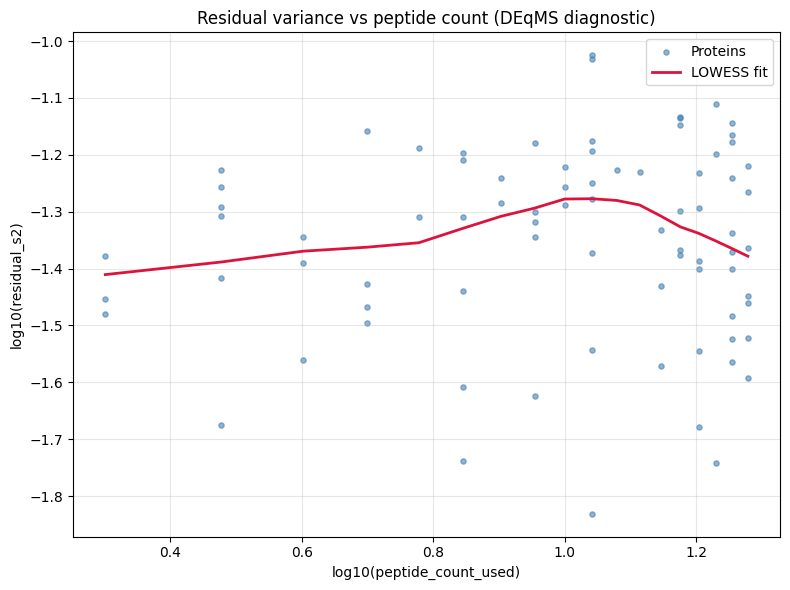

In [23]:
ptk.plot_variance_vs_peptide_count(results_deqms)
plt.show()

### 4d. `moderation="intensity_trend"` *(default)* — limma-trend equivalent

Mass-spectrometry counting noise is roughly Poisson, so per-feature
standard deviation scales with √intensity. The `intensity_trend` prior
captures that directly by LOWESS-fitting the variance-intensity trend
across all (feature, group) pairs. This is the Python equivalent of
limma's `trend=TRUE` and the recommended default for MS data.

In [ ]:
config.moderation = 'intensity_trend'   # the default; set explicitly here for clarity
results_trend = ptk.run_comprehensive_statistical_analysis(
    data, meta_dict, config, protein_annotations=annot
)
print(f"Significant at FDR < 0.05: {(results_trend['adj.P.Val'] < 0.05).sum()}")
results_trend.sort_values('P.Value').head(5)[
    ['Protein', 'Protein Gene', 'logFC', 'adj.P.Val', 'intensity_used']
]

Diagnostic: per-(feature, group) SD vs √intensity with the LOWESS prior
overlaid. A roughly linear cloud with slope ≈ `k` indicates Poisson-like
counting noise, which is exactly what the `intensity_trend` prior
leverages.

In [ ]:
ptk.plot_variance_vs_intensity(results_trend)
plt.show()

## 5. Volcano plot and PCA


Volcano Plot (FC > 1.0, FDR < 0.05)


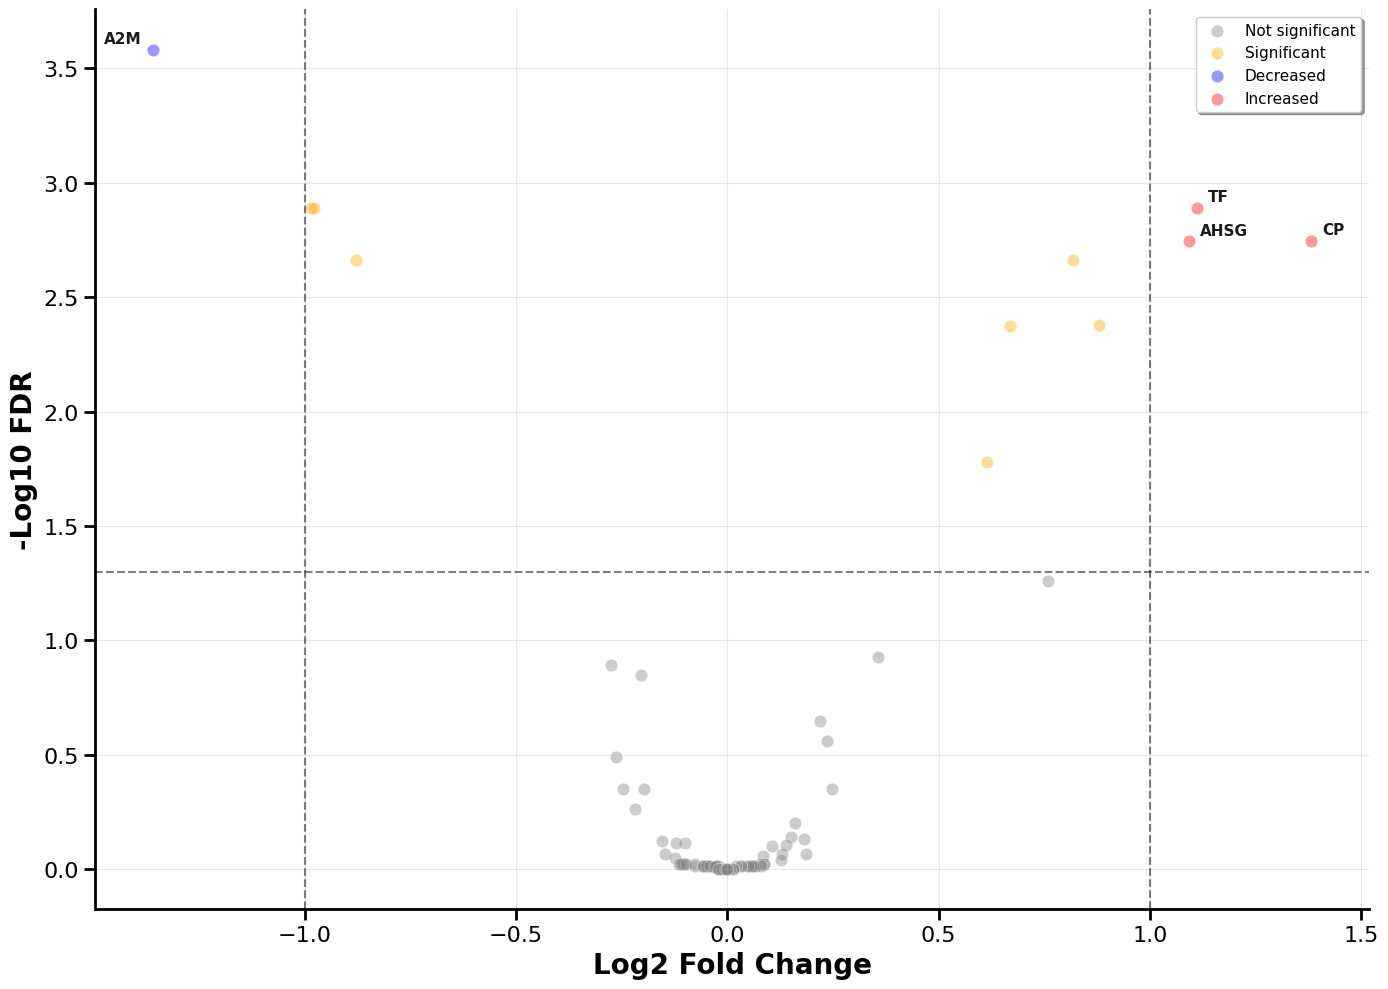

Volcano plot summary:
Total proteins: 80
P-value type used: FDR (adjusted)
Significant (FDR < 0.05): 11
Up-regulated (FC > 1.0, FDR < 0.05): 3
Down-regulated (FC < -1.0, FDR < 0.05): 1


In [24]:
ptk.plot_volcano(results, fc_threshold=1.0, gene_column='Protein Gene', label_top_n=10)
plt.show()

/mnt/c/Users/macco/Documents/GitHub/uw-maccosslab/proteomics-toolkit/proteomics_toolkit/visualization.py:1051: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(


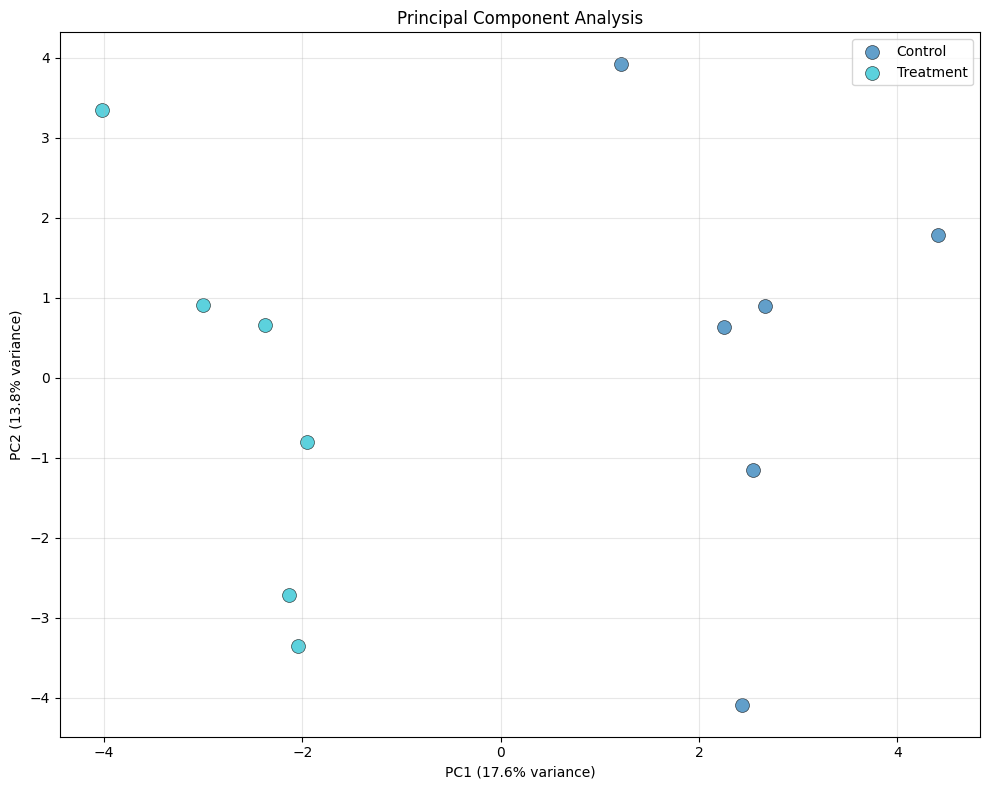

PCA summary:
PC1 explains 17.6% of variance
PC2 explains 13.8% of variance
Total variance explained: 31.4%


In [25]:
ptk.plot_pca(data, sample_cols, meta_dict)
plt.show()

## 6. Peptide coverage for a significant protein

Pick the most significant protein and inspect its peptide-level coverage
along the parent-protein sequence. The coverage map renders the protein
sequence as monospaced text, draws each peptide bar at its true
start/end residue positions, wraps long proteins to multiple rows, and
colours each bar by abundance (default), fold-change, or detection
frequency.

We pass the parent-protein sequence from the bundled
`protein_sequences` dict. In your own analysis you'd typically load
sequences from a FASTA file with `ptk.load_fasta_sequences(path)`.

In [ ]:
top_protein = results.sort_values('P.Value').iloc[0]['Protein']
print(f"Top hit: {top_protein}")

if (peptide_data['leading_protein'] == top_protein).any() and top_protein in protein_sequences:
    # Default: colour by abundance
    ptk.plot_peptide_coverage_map(
        peptide_data,
        protein_id=top_protein,
        protein_sequence=protein_sequences[top_protein],
        sample_columns=sample_cols,
        color_by='abundance',
    )
    plt.show()

    # Alternative: colour by Control-vs-Treatment fold-change
    ptk.plot_peptide_coverage_map(
        peptide_data,
        protein_id=top_protein,
        protein_sequence=protein_sequences[top_protein],
        sample_columns=sample_cols,
        color_by='fold_change',
        sample_metadata=meta_dict,
        group_column='Group',
        group_labels=('Control', 'Treatment'),
    )
    plt.show()
else:
    print("Top hit has no peptide-level data or sequence in this bundled example.")

## 7. Export results

In [27]:
exported = ptk.export_analysis_results(
    normalized_data=data,
    sample_metadata=meta_dict,
    differential_results=results,
    filtered_data=data,
    output_prefix='example_analysis',
)
exported

Exporting analysis results...
Creating CLEAN normalized data with proper column ordering...
Using standardized structure: 13 sample columns (columns 6+)
Added: Protein
Added: Description
Added: Protein Gene
Added: UniProt_Accession
Added: UniProt_Entry_Name
Done: Final column order: 5 annotations + 13 samples
Done: CLEAN structure: No redundant or scattered columns!
Column order: ['Protein', 'Description', 'Protein Gene', 'UniProt_Accession', 'UniProt_Entry_Name']... + 13 sample columns
Note: NO redundant columns like 'Gene', 'UniProt_Database', extra 'Description' etc.
Normalized data (with annotations) exported to: example_analysis_normalized_data.csv
Sample metadata exported to: example_analysis_sample_metadata.csv
Adding annotation columns: ['Protein', 'Description', 'Protein Gene', 'UniProt_Accession', 'UniProt_Entry_Name']
Differential analysis results (with annotations) exported to: example_analysis_differential_results_annotated.csv

Exported results preview (columns: ['Protein

,Protein,Gene,logFC,P.Value,adj.P.Val
0,sp|P01023|A2MG_HUMAN,A2M,-1.359042,0.000003,0.000262
1,sp|P00738|HPT_HUMAN,HP,-0.984949,0.000041,0.001291
2,sp|P02787|TRFE_HUMAN,TF,1.110705,0.000050,0.001291


{'normalized_data': 'example_analysis_normalized_data.csv',
 'sample_metadata': 'example_analysis_sample_metadata.csv',
 'differential_results': 'example_analysis_differential_results_annotated.csv'}

That's it: a full protein-level workflow on 80 proteins in a handful of cells.
Swap `protein_data` for `peptide_data` (and adjust annotation columns) to run
the same pipeline at the peptide level.